# ABC Model

A three-variable ODE with:
- **Negative feedback loop** between A and B (integral feedback)
- **Tumor dynamics** driven by B

## Equations

$$\frac{dA}{dt} = a_1(\mu - B)$$

$$\frac{dB}{dt} = b_1 A - b_2 B$$

$$\frac{dC}{dt} = C\bigl(c_1 - c_2 \max(\mu - B,\, 0)\bigr)$$

**Interpretation:**
- $A$: compensatory adaptation
- $B$: cancer-supporting TME component (setpoint $\mu$)
- $C$: tumor size

**Topology:**
- $A$ activates $B$ (via $b_1 A$); $B$ inhibits $A$ (integral feedback) → $B_{ss} = \mu$
- Tumor grows at rate $c_1$; removal $c_2 \max(\mu-B, 0)$ is only active when $B < \mu$
- Treatment reduces $b_1$, pushing $B$ below $\mu$ and enabling tumor removal

**Steady states (off treatment):**
$$B_{ss} = \mu, \quad A_{ss} = \frac{b_2\,\mu}{b_1}$$

Off treatment: $B = \mu$ so $\max(\mu-B,0)=0$ and tumor grows at rate $c_1$.  
On treatment: $B < \mu$ and tumor removal $c_2(\mu-B)$ can overcome growth.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style

set_style()
plt.rcParams['text.usetex'] = False

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

In [24]:
# ======================================================================
# Parameters
# ======================================================================

mu = 1.0

# AB parameters
a1 = 1.0
b1 = 1.0   # A → B activation (halved by treatment)
b2 = 2.0

# C parameters
c1 = 0.1   # tumor growth rate
c2 = 1.0   # tumor removal rate (active when B < mu)

# Off-treatment steady states (B=mu by integral feedback)
B_ss = mu
A_ss = b2 * mu / b1

print(f"Off-treatment steady state: A={A_ss:.2f}, B={B_ss:.2f}")
print(f"Off-treatment: tumor grows at rate c1={c1} (no removal since B=mu)")

# Treatment: halve b1
b1_on = b1 / 2
A_ss_on = b2 * mu / b1_on
print(f"\nOn-treatment steady state (AB): A={A_ss_on:.2f}, B={B_ss:.2f}")
print(f"On-treatment: B transiently dips below mu → tumor removal active")

Off-treatment steady state: A=2.00, B=1.00
Off-treatment: tumor grows at rate c1=0.1 (no removal since B=mu)

On-treatment steady state (AB): A=4.00, B=1.00
On-treatment: B transiently dips below mu → tumor removal active


In [25]:
# ======================================================================
# ODE definition
# ======================================================================

def abc_rhs(t, y, b1_val):
    A, B, C = y
    dA = a1 * (mu - B)
    dB = b1_val * A - b2 * B
    dC = C * (c1 - c2 * max(mu - B, 0))
    return [dA, dB, dC]

In [26]:
# ======================================================================
# Simulation: start at off-treatment SS, apply treatment, then release
# ======================================================================

from scipy.integrate import odeint

# Initial condition: off-treatment steady state, tumor at C=1
y0 = [A_ss, B_ss, 1.0]

t_treatment = 10.0   # apply treatment at t=0, release at t=10
t_end       = 30.0   # end simulation at t=30

t1 = np.linspace(0, t_treatment, 300)
t2 = np.linspace(0, t_end - t_treatment, 600)

# Phase 1: on treatment (b1 halved)
sol1 = odeint(lambda y, t: abc_rhs(t, y, b1_on), y0, t1)
A1, B1, C1 = sol1.T

# Phase 2: off treatment (b1 restored)
sol2 = odeint(lambda y, t: abc_rhs(t, y, b1), sol1[-1], t2)
A2, B2, C2 = sol2.T

t_full = np.concatenate([t1, t_treatment + t2[1:]])
A_full = np.concatenate([A1, A2[1:]])
B_full = np.concatenate([B1, B2[1:]])
C_full = np.concatenate([C1, C2[1:]])

print("Simulation complete.")
print(f"  Final state: A={A_full[-1]:.3f}, B={B_full[-1]:.3f}, C={C_full[-1]:.3f}")

Simulation complete.
  Final state: A=2.000, B=1.000, C=3.092


/tmp/ipykernel_1334612/2918764802.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


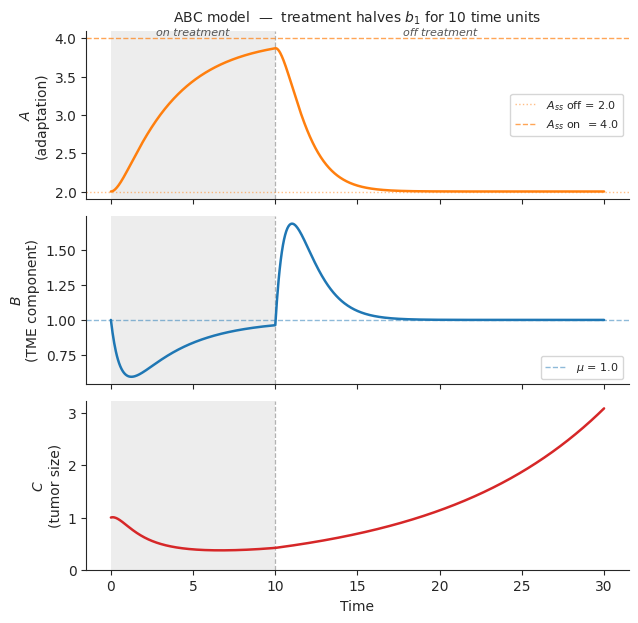

In [27]:
# ======================================================================
# Plot
# ======================================================================

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True,
                          gridspec_kw={'hspace': 0.1})

for ax in axes:
    ax.axvspan(0, t_treatment, color='lightgray', alpha=0.4, lw=0, zorder=0)
    ax.axvline(t_treatment, color='gray', ls='--', lw=0.9, alpha=0.6)
    clean_ax(ax)

axes[0].plot(t_full, A_full, color='C1', lw=1.8)
axes[0].axhline(A_ss,    color='C1', ls=':', lw=1.0, alpha=0.5, label=f'$A_{{ss}}$ off = {A_ss:.1f}')
axes[0].axhline(A_ss_on, color='C1', ls='--', lw=1.0, alpha=0.7, label=f'$A_{{ss}}$ on  = {A_ss_on:.1f}')
axes[0].set_ylabel('$A$\n(adaptation)')
axes[0].legend(fontsize=8, loc='center right')

axes[1].plot(t_full, B_full, color='C0', lw=1.8)
axes[1].axhline(B_ss, color='C0', ls='--', lw=1.0, alpha=0.5, label=f'$\\mu$ = {mu:.1f}')
axes[1].set_ylabel('$B$\n(TME component)')
axes[1].legend(fontsize=8, loc='lower right')

axes[2].plot(t_full, C_full, color='C3', lw=1.8)
axes[2].set_ylabel('$C$\n(tumor size)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

trans = axes[0].get_xaxis_transform()
kw = dict(ha='center', va='bottom', fontsize=8, color='#555555', fontstyle='italic', transform=trans)
axes[0].text(t_treatment / 2,                     0.96, 'on treatment', **kw)
axes[0].text((t_treatment + t_end) / 2,           0.96, 'off treatment', **kw)

axes[0].set_title(f'ABC model  —  treatment halves $b_1$ for {int(t_treatment)} time units', fontsize=10)

plt.tight_layout()
fig.savefig('abc_model_treatment.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1334612/4203207906.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


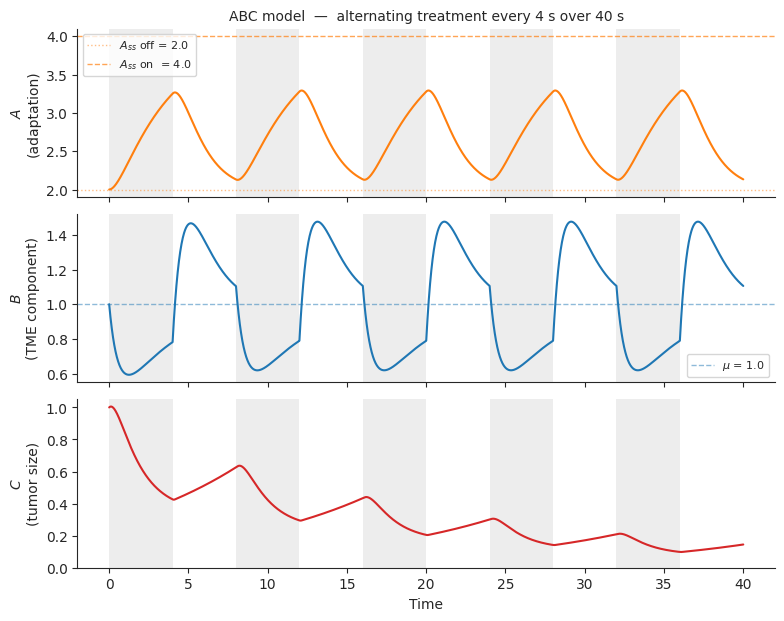

In [28]:
# ======================================================================
# Alternating treatment: switch every 4 seconds for 40 seconds total
# ======================================================================

t_switch = 4.0
t_total  = 40.0
n_cycles = int(t_total / t_switch)

t_all = []
A_all = []
B_all = []
C_all = []

y_cur = [A_ss, B_ss, 1.0]   # start at off-treatment SS
t_cur = 0.0

for i in range(n_cycles):
    b1_cur = b1_on if (i % 2 == 0) else b1   # start on treatment
    t_seg = np.linspace(0, t_switch, 200)
    sol = odeint(lambda y, t: abc_rhs(t, y, b1_cur), y_cur, t_seg)
    t_all.append(t_cur + t_seg)
    A_all.append(sol[:, 0])
    B_all.append(sol[:, 1])
    C_all.append(sol[:, 2])
    t_cur += t_switch
    y_cur = sol[-1]

t_cyc = np.concatenate(t_all)
A_cyc = np.concatenate(A_all)
B_cyc = np.concatenate(B_all)
C_cyc = np.concatenate(C_all)

# --- plot ---
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True,
                          gridspec_kw={'hspace': 0.1})

# shade treatment periods (even cycles)
for i in range(n_cycles):
    if i % 2 == 0:
        for ax in axes:
            ax.axvspan(i * t_switch, (i + 1) * t_switch,
                       color='lightgray', alpha=0.4, lw=0, zorder=0)

for ax in axes:
    clean_ax(ax)

axes[0].plot(t_cyc, A_cyc, color='C1', lw=1.5)
axes[0].axhline(A_ss,    color='C1', ls=':', lw=1.0, alpha=0.5, label=f'$A_{{ss}}$ off = {A_ss:.1f}')
axes[0].axhline(A_ss_on, color='C1', ls='--', lw=1.0, alpha=0.7, label=f'$A_{{ss}}$ on  = {A_ss_on:.1f}')
axes[0].set_ylabel('$A$\n(adaptation)')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(t_cyc, B_cyc, color='C0', lw=1.5)
axes[1].axhline(B_ss, color='C0', ls='--', lw=1.0, alpha=0.5, label=f'$\\mu$ = {mu:.1f}')
axes[1].set_ylabel('$B$\n(TME component)')
axes[1].legend(fontsize=8, loc='lower right')

axes[2].plot(t_cyc, C_cyc, color='C3', lw=1.5)
axes[2].set_ylabel('$C$\n(tumor size)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

axes[0].set_title(f'ABC model  —  alternating treatment every {t_switch:.0f} s over {t_total:.0f} s', fontsize=10)

plt.tight_layout()
fig.savefig('abc_model_cycling.pdf', bbox_inches='tight')
plt.show()

# Analytical Analysis of the ABC Model

## Tumor shrinkage condition

Since $C > 0$, we can divide $\dot{C} = C(c_1 - c_2(\mu-B)^+)$ by $C$ and integrate:

$$\ln\frac{C(T)}{C(0)} = c_1 T - c_2 \int_0^T (\mu - B)^+\, dt$$

For tumor shrinkage over $[0, T]$ we need $C(T) < C(0)$, i.e. the left side $< 0$:

$$\boxed{\frac{c_1}{c_2} < \frac{1}{T}\int_0^T (\mu - B)^+\, dt}$$

The **time-averaged dip of $B$ below $\mu$** must exceed $c_1/c_2$.

Treatment works by pushing $B$ below $\mu$; integral feedback then drives $B$ back, but by how much and for how long depends on $b_1$, $b_2$, $a_1$.

## AB subsystem — eigenvalue analysis

The $(A, B)$ dynamics linearize around any point as:

$$J = \begin{pmatrix} 0 & -a_1 \\ b_1 & -b_2 \end{pmatrix}, \qquad \lambda_{1,2} = \frac{-b_2 \pm \sqrt{b_2^2 - 4\,a_1 b_1}}{2}$$

Both eigenvalues always have negative real part (stable), since $a_1, b_1, b_2 > 0$.

**Note:** with the default parameters ($a_1=1, b_1=1, b_2=2$), $b_2^2 - 4a_1b_1 = 0$ exactly, so the off-treatment system is *critically damped* — a coincidence of the chosen parameters, not a general property.

In [29]:
import sympy as sp

t_s = sp.Symbol('t', real=True, positive=True)
a1_s, b1_s, b2_s, mu_s = sp.symbols('a1 b1 b2 mu', positive=True)

# Jacobian
J = sp.Matrix([[0, -a1_s], [b1_s, -b2_s]])
eigs = J.eigenvals()
lam = list(eigs.keys())
print("General eigenvalues:")
for l in lam:
    print(" ", sp.simplify(l))

# Evaluate for our two parameter sets
p_off = {a1_s: a1, b1_s: b1,    b2_s: b2, mu_s: mu}
p_on  = {a1_s: a1, b1_s: b1_on, b2_s: b2, mu_s: mu}

lam_off = sorted([complex(l.subs(p_off)) for l in lam], key=lambda x: x.real)
lam_on  = sorted([complex(l.subs(p_on))  for l in lam], key=lambda x: x.real)

print(f"\nOff-treatment eigenvalues: {[f'{l.real:.4f}' for l in lam_off]}")
print(f"On-treatment  eigenvalues: {[f'{l.real:.4f}' for l in lam_on]}")

# Recovery time constant from the dominant (slowest) eigenvalue off-treatment
dom_eig_off = max(lam_off, key=lambda x: x.real)
tau = 1.0 / abs(dom_eig_off.real)
print(f"\nDominant off-treatment eigenvalue: {dom_eig_off.real:.4f}")
print(f"Time constant τ = {tau:.2f}")
print(f"95% recovery ≈ 3τ = {3*tau:.2f}")
print(f"99% recovery ≈ 4.6τ = {4.6*tau:.2f}")
print(f"(These are approximate — critically damped system has te^(-t) terms)")

# Shrinkage condition threshold for current parameters
print(f"\nShrinkage condition threshold  c1/c2 = {c1/c2:.4f}")
print(f"Treatment must maintain  avg[(mu-B)+] > {c1/c2:.4f}  over the treatment window")

General eigenvalues:
  -b2/2 - sqrt(-4*a1*b1 + b2**2)/2
  -b2/2 + sqrt(-4*a1*b1 + b2**2)/2

Off-treatment eigenvalues: ['-1.0000', '-1.0000']
On-treatment  eigenvalues: ['-1.7071', '-0.2929']

Dominant off-treatment eigenvalue: -1.0000
Time constant τ = 1.00
95% recovery ≈ 3τ = 3.00
99% recovery ≈ 4.6τ = 4.60
(These are approximate — critically damped system has te^(-t) terms)

Shrinkage condition threshold  c1/c2 = 0.1000
Treatment must maintain  avg[(mu-B)+] > 0.1000  over the treatment window


/tmp/ipykernel_1334612/3797046877.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


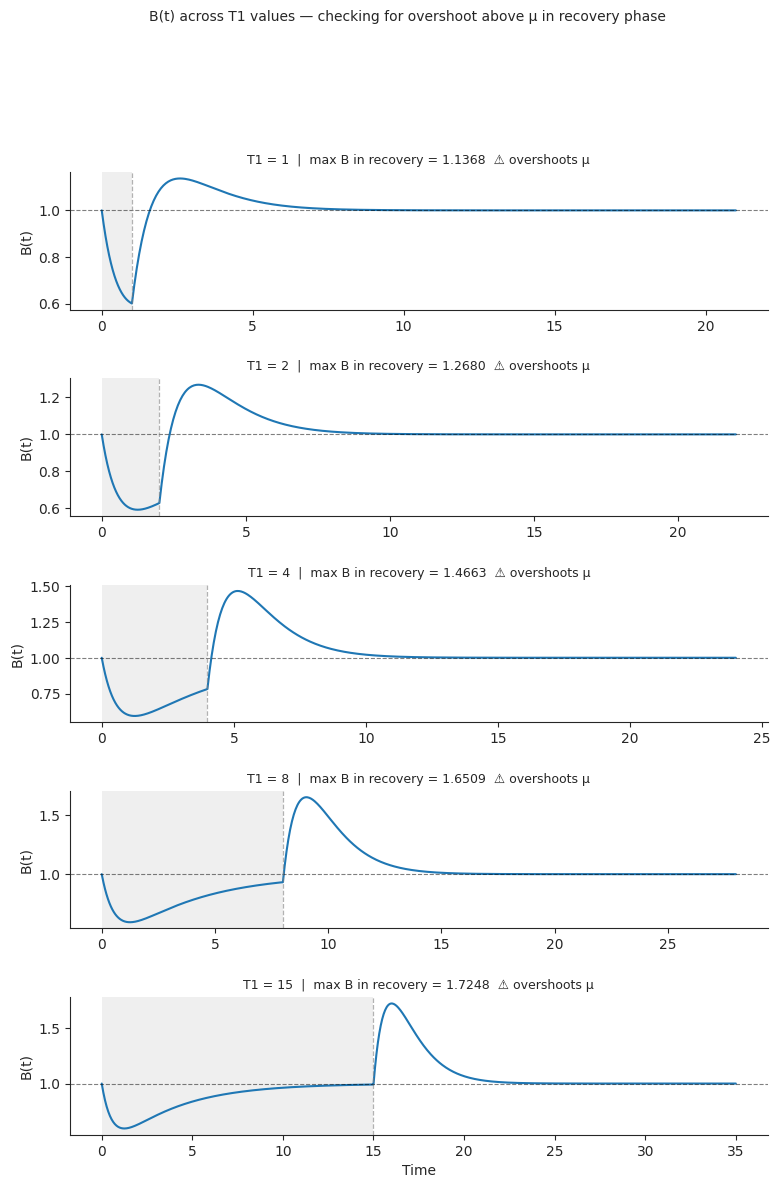

In [30]:
# ======================================================================
# Does B overshoot mu during Phase 2 (recovery)?
# Test across a range of T1 values and check max(B) in recovery phase
# ======================================================================

T2 = 20.0   # long recovery window so we can see the full trajectory

T1_values = [1, 2, 4, 8, 15]
fig, axes = plt.subplots(len(T1_values), 1, figsize=(9, 2.5 * len(T1_values)),
                          sharex=False, gridspec_kw={'hspace': 0.5})

for ax, T1_test in zip(axes, T1_values):
    t1 = np.linspace(0, T1_test, 500)
    t2 = np.linspace(0, T2, 500)

    sol1 = odeint(lambda y, t: abc_rhs(t, y, b1_on), [A_ss, B_ss, 1.0], t1)
    sol2 = odeint(lambda y, t: abc_rhs(t, y, b1),    sol1[-1],          t2)

    B1 = sol1[:, 1]
    B2 = sol2[:, 1]
    t_full_test = np.concatenate([t1, T1_test + t2[1:]])
    B_full_test = np.concatenate([B1, B2[1:]])

    ax.plot(t_full_test, B_full_test, color='C0', lw=1.5)
    ax.axhline(mu, color='k', ls='--', lw=0.8, alpha=0.5, label=f'μ = {mu}')
    ax.axvline(T1_test, color='gray', ls='--', lw=0.9, alpha=0.6)
    ax.axvspan(0, T1_test, color='lightgray', alpha=0.35, lw=0, zorder=0)

    B2_max = B2.max()
    overshoot = B2_max > mu + 1e-6
    ax.set_title(f'T1 = {T1_test}  |  max B in recovery = {B2_max:.4f}  '
                 f'{"⚠ overshoots μ" if overshoot else "✓ stays ≤ μ"}', fontsize=9)
    ax.set_ylabel('B(t)')
    clean_ax(ax)

axes[-1].set_xlabel('Time')
plt.suptitle('B(t) across T1 values — checking for overshoot above μ in recovery phase',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

# Optimal Treatment Duration — Numerical & Analytical

## Objective

Maximize the time-averaged dip of $B$ below $\mu$ over one on/off cycle:

$$J(T_1) = \frac{I_1(T_1) + I_2(T_1)}{T_1 + T_2}$$

## Choosing T2

After the zero-crossing $\tau^*$ where $B_{off}(\tau^*) = \mu$, we have $B > \mu$ and $(\mu - B)^+ = 0$ — the integral accumulates nothing further. Extending $T_2$ beyond $\tau^*$ only grows the denominator and hurts $J$. So the optimal recovery time is simply:
$$T_2 = \tau^* = -K_1 / K_2$$

## Analytical expressions

**Phase 1** — $B$ stays below $\mu$ throughout:
$$I_1(T_1) = \frac{-v_0}{\lambda_1 - \lambda_2}\left[\frac{e^{\lambda_1 T_1}-1}{\lambda_1} - \frac{e^{\lambda_2 T_1}-1}{\lambda_2}\right], \quad v_0 = b_{1,on}\frac{b_2\mu}{b_{1,off}} - b_2\mu$$

**Phase 2** — integrate only to $\tau^*$ (B overshoots $\mu$ after that):
$$I_2(T_1) = K_2\,e^{-\tau^*} - K_1 - K_2$$
where $K_1 = B_{end} - \mu$, $K_2 = v_{new} + K_1$, $v_{new} = b_{1,off} A_{end} - b_2 B_{end}$, $A_{end} = (\dot{B}_{end} + b_2 B_{end})/b_{1,on}$.

In [ ]:
from scipy.optimize import minimize

# ── Numerical multi-cycle objective ───────────────────────────────────
def J_multicycle(T1, T2, n_cycles=6):
    """Simulate n_cycles on/off cycles; return avg (mu-B)+ per unit time."""
    def rhs(y, t, b1_val):
        A, B, _, I = y
        return [a1*(mu - B), b1_val*A - b2*B, 0.0, max(mu - B, 0)]

    y_cur = [A_ss, B_ss, 1.0, 0.0]
    for _ in range(n_cycles):
        t_on  = np.linspace(0, T1, 200)
        y_cur = odeint(lambda y, t: rhs(y, t, b1_on), y_cur, t_on)[-1]
        t_off = np.linspace(0, T2, 200)
        y_cur = odeint(lambda y, t: rhs(y, t, b1),    y_cur, t_off)[-1]

    return y_cur[3] / (n_cycles * (T1 + T2))

# ── 2D heatmap ────────────────────────────────────────────────────────
T1_grid = np.linspace(0.5, 12, 50)
T2_grid = np.linspace(0.5, 12, 50)
J_grid  = np.array([[J_multicycle(t1, t2) for t2 in T2_grid] for t1 in T1_grid])

# ── Joint optimization ────────────────────────────────────────────────
res = minimize(
    lambda x: -J_multicycle(x[0], x[1]),
    x0=[3.0, 3.0],
    bounds=[(0.1, 20), (0.1, 20)],
    method='L-BFGS-B'
)
T1_opt, T2_opt = res.x
J_opt = -res.fun
print(f"Optimal T1 = {T1_opt:.3f},  T2 = {T2_opt:.3f},  J* = {J_opt:.5f}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(T2_grid, T1_grid, J_grid, levels=40, cmap='viridis')
fig.colorbar(im, ax=ax, label='$J(T_1, T_2)$')
ax.contour(T2_grid, T1_grid, J_grid,
           levels=[c1/c2], colors='white', linewidths=1.2, linestyles='--')
ax.plot(T2_opt, T1_opt, 'r*', ms=12, label=f'Optimum\n$T_1={T1_opt:.2f}$, $T_2={T2_opt:.2f}$')
ax.set_xlabel('$T_2$')
ax.set_ylabel('$T_1$')
ax.set_title('$J(T_1, T_2)$ over multiple cycles\n(white dashed: shrinkage threshold $c_1/c_2$)')
ax.legend(fontsize=8, loc='upper right')
clean_ax(ax)
plt.tight_layout()
plt.show()

T1 = 4.209,  T2 = 2.609,  cycle duration = 6.818


/tmp/ipykernel_1334612/914457742.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


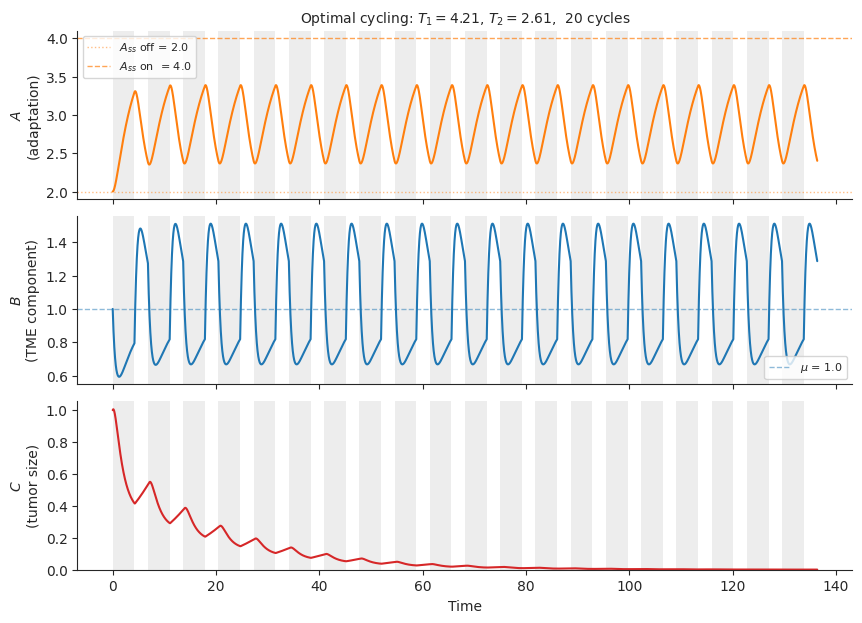

In [50]:
# ======================================================================
# Multi-cycle simulation using jointly optimal T1 and T2
# ======================================================================

n_cycles = 20

print(f"T1 = {T1_opt:.3f},  T2 = {T2_opt:.3f},  cycle duration = {T1_opt + T2_opt:.3f}")

t_all, A_all, B_all, C_all = [], [], [], []
y_cur = [A_ss, B_ss, 1.0]
t_cur = 0.0

for i in range(n_cycles):
    # ON phase
    t_on = np.linspace(0, T1_opt, 300)
    s_on = odeint(lambda y, t: abc_rhs(t, y, b1_on), y_cur, t_on)
    t_all.append(t_cur + t_on);  A_all.append(s_on[:,0]);  B_all.append(s_on[:,1]);  C_all.append(s_on[:,2])
    t_cur += T1_opt;  y_cur = s_on[-1]

    # OFF phase
    t_off = np.linspace(0, T2_opt, 300)
    s_off = odeint(lambda y, t: abc_rhs(t, y, b1), y_cur, t_off)
    t_all.append(t_cur + t_off);  A_all.append(s_off[:,0]);  B_all.append(s_off[:,1]);  C_all.append(s_off[:,2])
    t_cur += T2_opt;  y_cur = s_off[-1]

t_cyc = np.concatenate(t_all)
A_cyc = np.concatenate(A_all)
B_cyc = np.concatenate(B_all)
C_cyc = np.concatenate(C_all)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, gridspec_kw={'hspace': 0.1})

for i in range(n_cycles):
    t_start = i * (T1_opt + T2_opt)
    for ax in axes:
        ax.axvspan(t_start, t_start + T1_opt, color='lightgray', alpha=0.4, lw=0, zorder=0)

for ax in axes:
    clean_ax(ax)

axes[0].plot(t_cyc, A_cyc, color='C1', lw=1.5)
axes[0].axhline(A_ss,    color='C1', ls=':',  lw=1.0, alpha=0.5, label=f'$A_{{ss}}$ off = {A_ss:.1f}')
axes[0].axhline(A_ss_on, color='C1', ls='--', lw=1.0, alpha=0.7, label=f'$A_{{ss}}$ on  = {A_ss_on:.1f}')
axes[0].set_ylabel('$A$\n(adaptation)')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(t_cyc, B_cyc, color='C0', lw=1.5)
axes[1].axhline(mu, color='C0', ls='--', lw=1.0, alpha=0.5, label=f'$\\mu$ = {mu:.1f}')
axes[1].set_ylabel('$B$\n(TME component)')
axes[1].legend(fontsize=8, loc='lower right')

axes[2].plot(t_cyc, C_cyc, color='C3', lw=1.5)
axes[2].set_ylabel('$C$\n(tumor size)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

axes[0].set_title(
    f'Optimal cycling: $T_1={T1_opt:.2f}$, $T_2={T2_opt:.2f}$,  {n_cycles} cycles',
    fontsize=10)

plt.tight_layout()
fig.savefig('abc_model_optimal_cycling.pdf', bbox_inches='tight')
plt.show()